# Step 1: Import the Libraby 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Step 2: Load The Data

In [2]:
df = pd.read_csv('diabetic_data.csv') 

# Force pandas to show all column in the output
pd.set_option('display.max_columns', None) 

# Look at first 5 Rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df1 = pd.read_csv('IDS_mapping.csv')
df1.head(10)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


In [4]:
df.shape

(101766, 50)

In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Step 3: Data Cleaning 

In [6]:
## Only show columns with missing values

missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [7]:
## Duplicate Data 

df.duplicated().sum()

np.int64(0)

In [8]:
# values are represented as '?'

for col in df.columns:
    if df[col].dtype == object:
        print(col,df[col][df[col]=='?'].count())

race 2273
gender 0
age 0
weight 98569
payer_code 40256
medical_specialty 49949
diag_1 21
diag_2 358
diag_3 1423
max_glu_serum 0
A1Cresult 0
metformin 0
repaglinide 0
nateglinide 0
chlorpropamide 0
glimepiride 0
acetohexamide 0
glipizide 0
glyburide 0
tolbutamide 0
pioglitazone 0
rosiglitazone 0
acarbose 0
miglitol 0
troglitazone 0
tolazamide 0
examide 0
citoglipton 0
insulin 0
glyburide-metformin 0
glipizide-metformin 0
glimepiride-pioglitazone 0
metformin-rosiglitazone 0
metformin-pioglitazone 0
change 0
diabetesMed 0
readmitted 0


In [9]:
# List of  columns  50% < missing values and '?' to drop

Null_cols = ['weight','payer_code','medical_specialty','max_glu_serum','A1Cresult']

# Drop columns from your DataFrame
df = df.drop(columns=Null_cols, errors='ignore')

In [10]:
# Now shape 

df.shape 

(101766, 45)

In [11]:
## Replace  '?' with common value  in race 

df['race'] = df['race'].replace('?',df['race'].mode()[0])

In [12]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [13]:
# remove all rows where the gender is 'Unknown/Invalid'

df = df[df['gender'] != 'Unknown/Invalid']

## Step 4: Feature Engineering 

In [14]:
df['admission_type_id'].value_counts()

admission_type_id
1    53988
3    18868
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [15]:
df['admission_source_id'].value_counts()

admission_source_id
7     57492
1     29564
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
8        16
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64

In [16]:
df['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     60232
3     13954
6     12902
18     3691
2      2128
22     1992
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

 Readmission type id, admission source id, discharge disposition id columns values - Nominal data type but its
 Data type are integer data type and very few columns id have most its of frequent values  

Fix:change data type into string and keep frequent values  and  all other values as ""Others 

In [17]:
# change data type 
df['admission_type_id']          = df['admission_type_id'].astype(str)
df['admission_source_id']        = df['admission_source_id'].astype(str)
df['discharge_disposition_id']   = df['discharge_disposition_id'].astype(str)

In [18]:
Top_admission_id     = df['admission_type_id'].value_counts().index[:5].tolist()
Top_source_id        = df['admission_source_id'].value_counts().index[:8].tolist()
Top_discharge_id     = df['discharge_disposition_id'].value_counts().index[:10].tolist() 

In [19]:
def Admission_ID_maping(ID):
    if ID in Top_admission_id:
        return ID
    else:
         return "others"   
    
df['admission_type_id'] = df['admission_type_id'].apply(Admission_ID_maping)
    

In [20]:
def source_id_maping(source_id):
    
    if source_id in Top_source_id:
        return source_id
    else:
        return "others"
    
df['admission_source_id'] = df['admission_source_id'].apply(source_id_maping) 

In [21]:
def discharge_id_maping(discharge_id):
    
    if discharge_id in Top_discharge_id:
        return discharge_id
    else:
        return "others"
    
df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(discharge_id_maping)    

In [22]:
df['diag_1'].unique()

array(['250.83', '276', '648', '8', '197', '414', '428', '398', '434',
       '250.7', '157', '518', '999', '410', '682', '402', '737', '572',
       'V57', '189', '786', '427', '996', '277', '584', '462', '473',
       '411', '174', '486', '998', '511', '432', '626', '295', '196',
       '250.6', '618', '182', '845', '423', '808', '250.4', '722', '403',
       '250.11', '784', '707', '440', '151', '715', '997', '198', '564',
       '812', '38', '590', '556', '578', '250.32', '433', 'V58', '569',
       '185', '536', '255', '250.13', '599', '558', '574', '491', '560',
       '244', '250.03', '577', '730', '188', '824', '250.8', '332', '562',
       '291', '296', '510', '401', '263', '438', '70', '250.02', '493',
       '642', '625', '571', '738', '593', '250.42', '807', '456', '446',
       '575', '250.41', '820', '515', '780', '250.22', '995', '235',
       '250.82', '721', '787', '162', '724', '282', '514', 'V55', '281',
       '250.33', '530', '466', '435', '250.12', 'V53', '789', '

#### Replace "?" with 'other'  

#### Mapped diag Code Range into Clinical Category 

In [23]:
def map_category(code):
    if code == '?' or code is None:
        return 'Other' 
    
    # Handle codes that start with letters (V or E codes)
    if str(code)[0].isalpha():
        return 'Other'
        
    try:
        val = float(code)
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif int(val) == 250:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# Apply the mapping to  diag_1, diag_2, diag_3 columns 
df['diag_1'] = df['diag_1'].apply(map_category)
df['diag_2'] = df['diag_2'].apply(map_category)
df['diag_3'] = df['diag_3'].apply(map_category)


In [24]:
df['diag_2'].value_counts(ascending= False).head(10)

diag_2
Circulatory        31880
Other              26911
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2426
Musculoskeletal     1764
Name: count, dtype: int64

In [25]:
df['readmitted'].value_counts()

readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64

#### Transformation Readmitted: Combine >30 and <30 into a single class (1), and keep NO as 0.

In [26]:
def readmitted(x):
    if x == "NO":
        return 0
    else:
        return 1 
df['readmitted'] = df['readmitted'].apply(readmitted)

# Step 4: Exploratory Data Analysis (EDA)

###  Distribution of Categorical Features

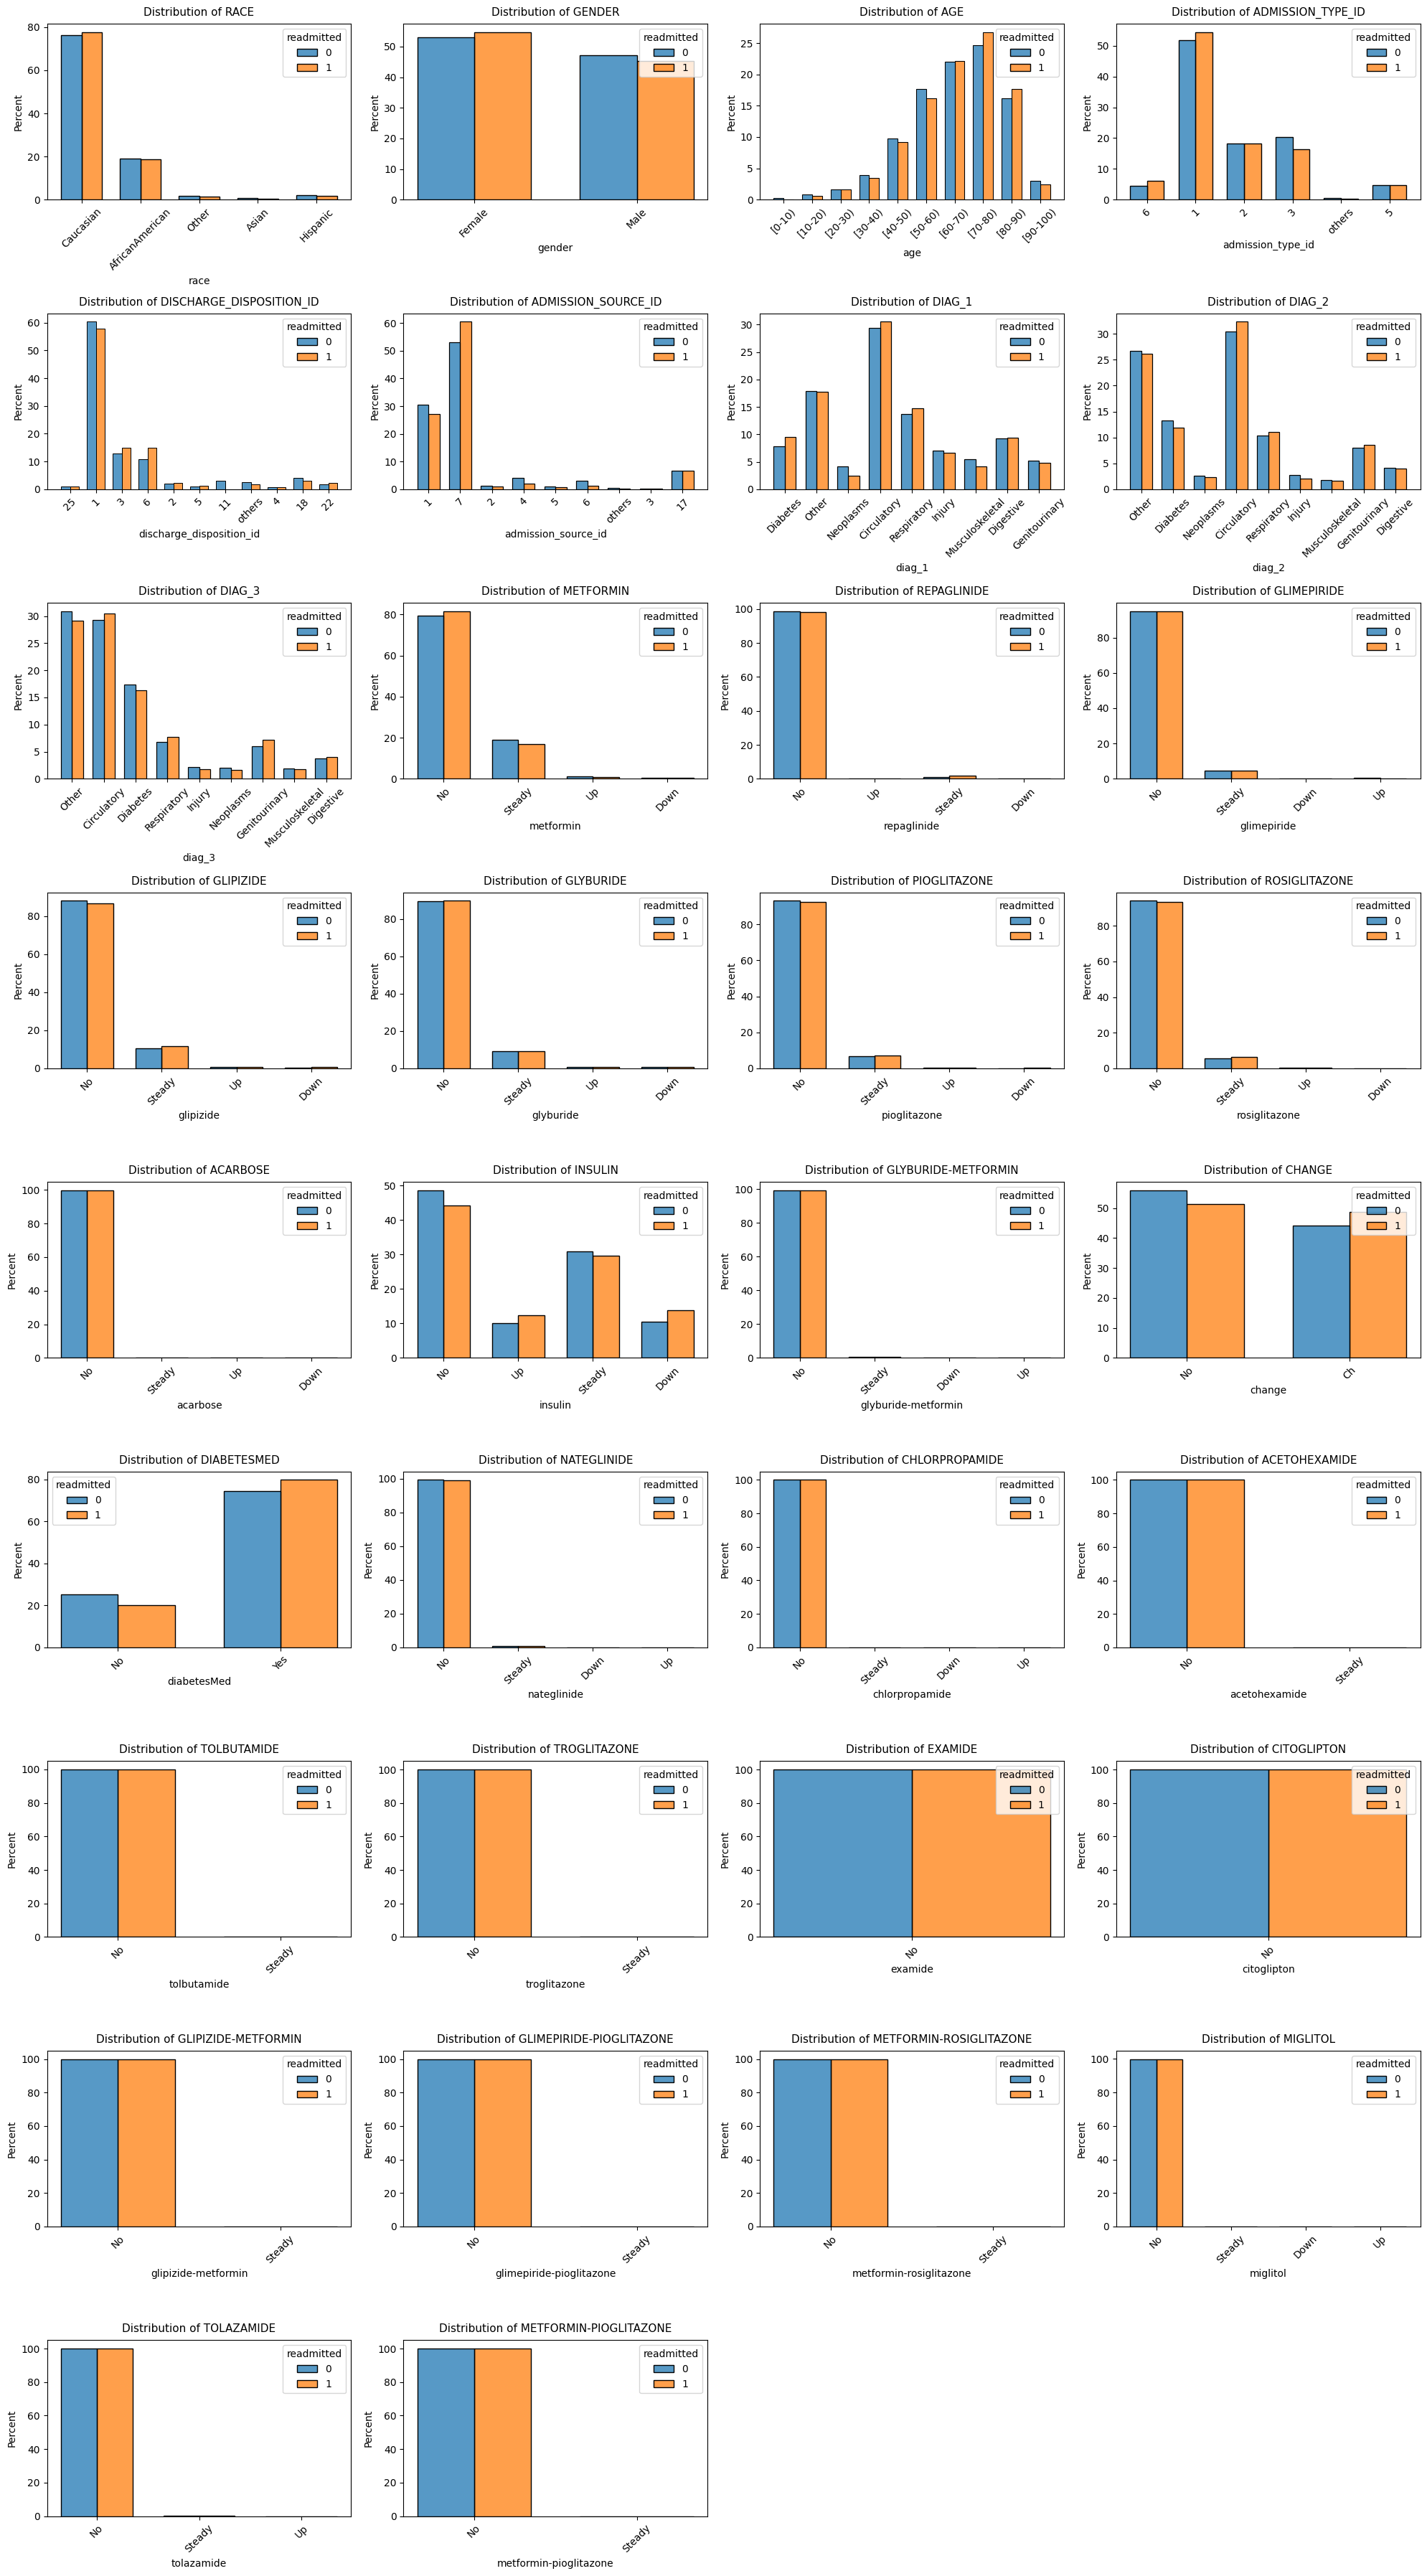

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

Categorical_Features = [
    'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed',
    'nateglinide','chlorpropamide','acetohexamide', 'tolbutamide', 'troglitazone', 'examide', 'citoglipton',
    'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone','miglitol','tolazamide',
    'metformin-pioglitazone'
]

# 1. Define grid dimensions (4 columns)
n_cols = 4  # Set to 4 for wider individual subplots
n_rows = math.ceil(len(Categorical_Features) / n_cols)

# 2. Create figure canvas 
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))

# 3. Flatten axes array
axes = axes.flatten()

# 4. Populate each subplot
for i, feature in enumerate(Categorical_Features):
    sns.histplot(
        data=df,
        x=feature,
        hue='readmitted',
        multiple='dodge',
        stat='percent',
        common_norm=False,
        ax=axes[i],
        shrink=0.7
    )
    axes[i].set_title(f'Distribution of {feature.upper()}', fontsize=11, pad=8)
    axes[i].tick_params(axis='x', labelrotation=45)

# 5. Hide unused axes 
for j in range(len(Categorical_Features), len(axes)):
    fig.delaxes(axes[j])

# 6. Final layout adjustments
plt.tight_layout()
plt.show()

In [28]:
df['examide'].value_counts()

examide
No    101763
Name: count, dtype: int64

### Drop Low-Variance Categorical Features
Remove medication columns where >95% of patients share the single value

In [29]:
# List of zero-variance columns to remove 
zero_var_cols = ['race','metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide',
                 'pioglitazone', 'rosiglitazone', 'acarbose','nateglinide','chlorpropamide',
                 'acetohexamide', 'tolbutamide', 'troglitazone', 'examide', 'citoglipton',
                'glimepiride-pioglitazone', 'metformin-rosiglitazone','miglitol','tolazamide',
                'metformin-pioglitazone','glyburide-metformin','glipizide-metformin','metformin-pioglitazone']

# Drop columns from your DataFrame
df = df.drop(columns=zero_var_cols, errors='ignore')

In [30]:
## Now Shape

df.shape

(101763, 22)

###  Distribution of Numeric Features

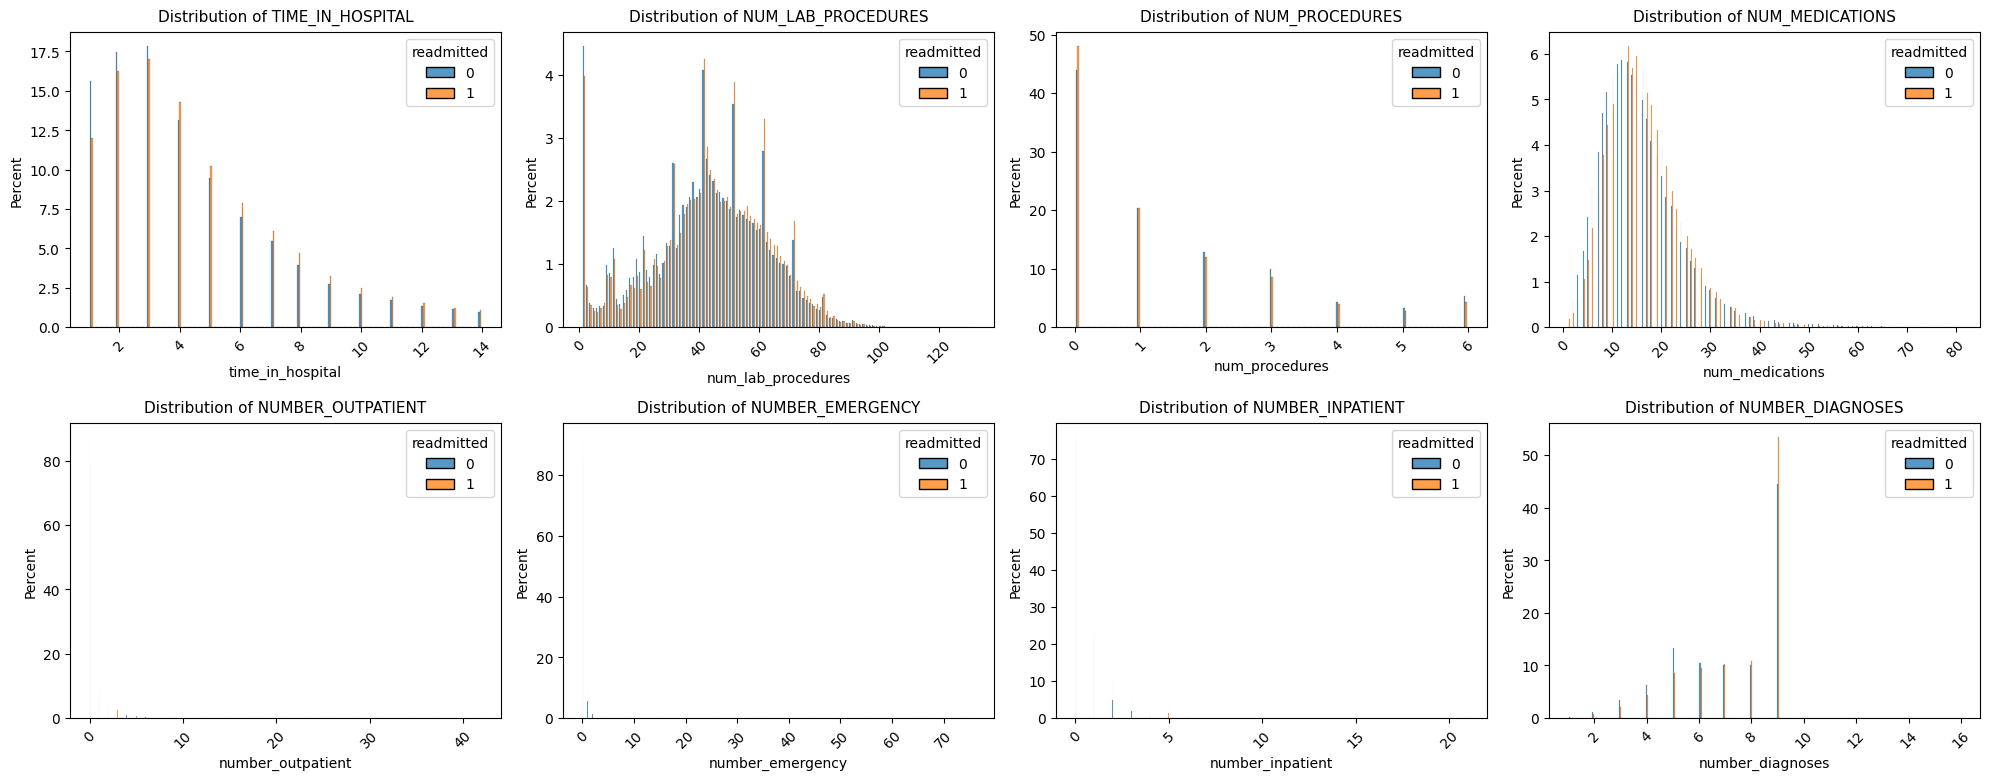

In [ ]:

Numeric_Features = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
                    'number_outpatient','number_emergency','number_inpatient','number_diagnoses']

# 1. Define grid dimensions ( 4 columns)
n_cols = 4  # Set to 4 for wider individual subplots
n_rows = math.ceil(len(Numeric_Features) / n_cols)

# 2. Create figure canvas (adjust width and row height per subplot)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))

# 3. Flatten axes array
axes = axes.flatten()

# 4. Populate each subplot
for i, feature in enumerate(Numeric_Features):
    sns.histplot(
        data=df,
        x=feature,
        hue='readmitted',
        multiple='dodge',
        stat='percent',
        common_norm=False,
        ax=axes[i],
        shrink=0.7
    )
    axes[i].set_title(f'Distribution of {feature.upper()}', fontsize=11, pad=8)
    axes[i].tick_params(axis='x', labelrotation=45)

# 5. Hide unused axes 
for j in range(len(Numeric_Features), len(axes)):
    fig.delaxes(axes[j])

# 6. Final layout adjustments
plt.tight_layout()
plt.show()

###  Correlation heatmap

<Axes: >

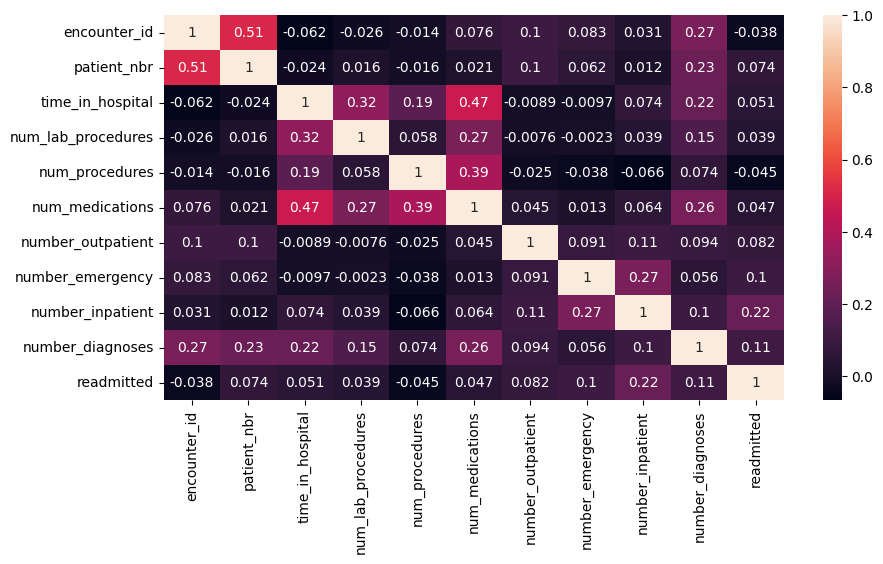

In [32]:
plt.figure(figsize = (10,5))
sns.heatmap(df.corr(numeric_only= True),annot= True)

### Checking Outliers

In [33]:
num_feature = df.select_dtypes(include= 'number')

Q1 = num_feature.quantile(0.25)
Q3 = num_feature.quantile(0.75)

IQR = Q3 - Q1
Lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

Outliers = (num_feature < Lower_bound )| (num_feature > upper_bound)
print(Outliers.sum())

encounter_id              0
patient_nbr             247
time_in_hospital       2252
num_lab_procedures      143
num_procedures         4954
num_medications        2557
number_outpatient     16739
number_emergency      11383
number_inpatient       7049
number_diagnoses        281
readmitted                0
dtype: int64


### Skewness

 near to 0 > Centralized (0.01, 0.002)

 negative > Left Skewed (-1.56)

 poistive (toward 1) > Right Skewed (1.256)

In [34]:
num_col = df.select_dtypes(include= 'number')
num_col.skew()

encounter_id           0.699166
patient_nbr            0.471325
time_in_hospital       1.134030
num_lab_procedures    -0.236531
num_procedures         1.316460
num_medications        1.326716
number_outpatient      8.832837
number_emergency      22.855272
number_inpatient       3.614085
number_diagnoses      -0.876799
readmitted             0.156905
dtype: float64

## Step 9: Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split 

skew_columns    = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
                   'number_outpatient','number_emergency','number_inpatient',"number_diagnoses"]


Nominal_columns = ['gender','admission_type_id','discharge_disposition_id','admission_source_id',
                   'diag_1','diag_2','diag_3','insulin','change','diabetesMed']

Ordinal_columns = ['age']

feature_cols    = skew_columns + Nominal_columns + Ordinal_columns  


x = df[feature_cols]

y = df['readmitted'] 

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size= 0.20 , random_state= 42)


In [36]:
df['age'].value_counts(ascending= False)

age
[70-80)     26066
[60-70)     22482
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

## Step 10. Preprocessing using ColumnTransformer 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer

# 1. skew feature
skew_pipeline  = Pipeline(steps= [
    ('log_transformer',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
    ])


# 2. ordinal feature
ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories= [['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)','[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']]))
    ])

# 3.nominal feature 

Nominal_pipeline = Pipeline(steps=[
    ('OHE',OneHotEncoder(handle_unknown= 'ignore'))
   ])


# Column Transformer 
preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline',skew_pipeline,skew_columns),
    ('ordinal_pipeline',ordinal_pipeline,Ordinal_columns),
    ('Nominal_pipeline',Nominal_pipeline,Nominal_columns)
   ])


## Step 12: Model Building

### import metrics 

In [38]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### 1. Logistic Regression


Deployment Threshold: 0.4

Train Accuracy:
 0.5881832698685665

Test Accuracy:
 0.5845329926792119

Readmission Precision:
 0.5297494428310934

Readmission Recall:
 0.8400985327192888

Readmission F1:
 0.6497680583167661

ROC-AUC:
 0.6869771010439487

TEST CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       0.73      0.37      0.49     11016
           1       0.53      0.84      0.65      9337

    accuracy                           0.58     20353
   macro avg       0.63      0.60      0.57     20353
weighted avg       0.64      0.58      0.56     20353


TRAIN CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       0.73      0.37      0.49     43845
           1       0.53      0.84      0.65     37565

    accuracy                           0.59     81410
   macro avg       0.63      0.61      0.57     81410
weighted avg       0.64      0.59      0.57     81410


CONFUSION MATRIX
 [[4053 6963]
 [1

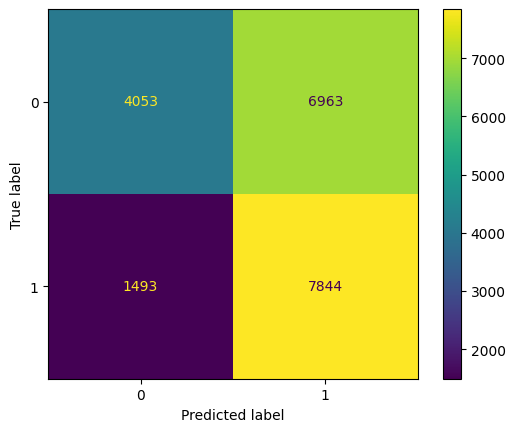

In [39]:

from sklearn.linear_model import LogisticRegression


## FIXED THRESHOLD
THRESHOLD = 0.40

Lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('Logistic Model',LogisticRegression(
                                                    max_iter=2000,
                                                    class_weight='balanced',
                                                    random_state=42
                                                    ))
])

Lr_pipeline.fit(x_train,y_train)

## Probability of Readmitted = class 1

lr_train_prob = Lr_pipeline.predict_proba(x_train)[:, 1]

lr_test_prob  = Lr_pipeline.predict_proba(x_test)[:, 1]

##  APPLY FIXED THRESHOLD = 0.40

lr_xtrain_predict = (lr_train_prob >= THRESHOLD).astype(int)

lr_predict        = (lr_test_prob >= THRESHOLD).astype(int)


## Evaluation 

lr_xtrain_accuracy  = accuracy_score(y_train, lr_xtrain_predict)

lr_predict_accuracy = accuracy_score(y_test,lr_predict)

## TRAIN CLASSIFICATION REPORT

lr_report_xtrain    = classification_report(y_train, lr_xtrain_predict)

## TEST CLASSIFICATION REPORT

lr_report        = classification_report(y_test, lr_predict)

lr_precision     = precision_score(y_test, lr_predict)

lr_recall       = recall_score(y_test, lr_predict)

lr_f1          = f1_score(y_test, lr_predict)

lr_roc_auc     = roc_auc_score(y_test, lr_test_prob)

lr_cm         = confusion_matrix(y_test, lr_predict)


## PRINT RESULTS

print("\nDeployment Threshold:", THRESHOLD)

print("\nTrain Accuracy:\n",lr_xtrain_accuracy)

print("\nTest Accuracy:\n",lr_predict_accuracy)

print("\nReadmission Precision:\n",lr_precision)

print("\nReadmission Recall:\n",lr_recall)

print("\nReadmission F1:\n",lr_f1)

print("\nROC-AUC:\n",lr_roc_auc)

print("\nTEST CLASSIFICATION REPORT\n",lr_report)

print("\nTRAIN CLASSIFICATION REPORT\n",lr_report_xtrain)

print("\nCONFUSION MATRIX\n",lr_cm)

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm
).plot()
plt.show()

### 2. Random Forest Classification


Deployment Threshold: 0.4

Test Accuracy:
 0.6103277158158502

Readmission Precision:
 0.553411335663273

Readmission Recall:
 0.7801220948912927

Readmission F1:
 0.6474954442419663

ROC-AUC:
 0.6890393452649982

TEST CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       0.71      0.47      0.56     11016
           1       0.55      0.78      0.65      9337

    accuracy                           0.61     20353
   macro avg       0.63      0.62      0.61     20353
weighted avg       0.64      0.61      0.60     20353


CONFUSION MATRIX
 [[5138 5878]
 [2053 7284]]


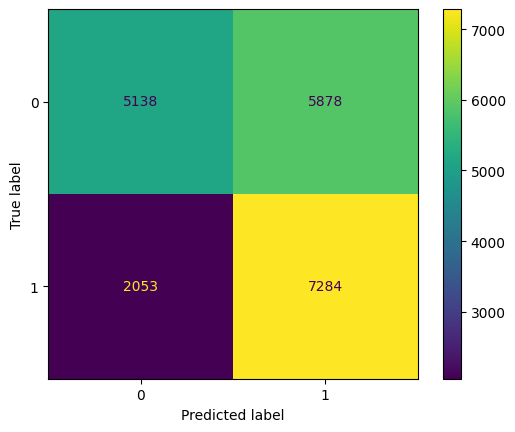

In [43]:
from sklearn.ensemble import RandomForestClassifier

## FIXED THRESHOLD
THRESHOLD = 0.40

rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('Model',RandomForestClassifier(n_estimators=200,
                                    random_state= 42,
                                    class_weight='balanced', 
                                    n_jobs=-1
                                    ))
])


rf_pipeline.fit(x_train,y_train)

rf_test_prob = rf_pipeline.predict_proba(x_test)[:, 1]

## predict at 0.40 THRESHOLD
rf_predict = (rf_test_prob >= THRESHOLD).astype(int)


## Evaluation 
rf_accuracy    = accuracy_score(y_test,rf_predict)

rf_report      = classification_report(y_test,rf_predict)

rf_precision  = precision_score(y_test,rf_predict)

rf_recall     = recall_score(y_test,rf_predict)

rf_f1         = f1_score(y_test,rf_predict)

rf_roc_auc   = roc_auc_score(y_test,rf_test_prob)

rf_cm = confusion_matrix(y_test,rf_predict)

#  PRINT RESULTS

print("\nDeployment Threshold:", THRESHOLD)


print("\nTest Accuracy:\n",rf_accuracy)

print("\nReadmission Precision:\n",rf_precision)

print("\nReadmission Recall:\n",rf_recall)

print("\nReadmission F1:\n",rf_f1)

print("\nROC-AUC:\n",rf_roc_auc)

print("\nTEST CLASSIFICATION REPORT\n",rf_report)

print("\nCONFUSION MATRIX\n",rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm
).plot()
plt.show()

### 3. XGBOOST Classification 


Deployment Threshold: 0.4

Test Accuracy:
 0.6233970422050803

Readmission Precision:
 0.5667624980035139

Readmission Recall:
 0.7600942486880155

Readmission F1:
 0.6493435198316483

ROC-AUC:
 0.6338143719838043

TEST CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       0.71      0.51      0.59     11016
           1       0.57      0.76      0.65      9337

    accuracy                           0.62     20353
   macro avg       0.64      0.63      0.62     20353
weighted avg       0.65      0.62      0.62     20353


CONFUSION MATRIX
 [[5591 5425]
 [2240 7097]]


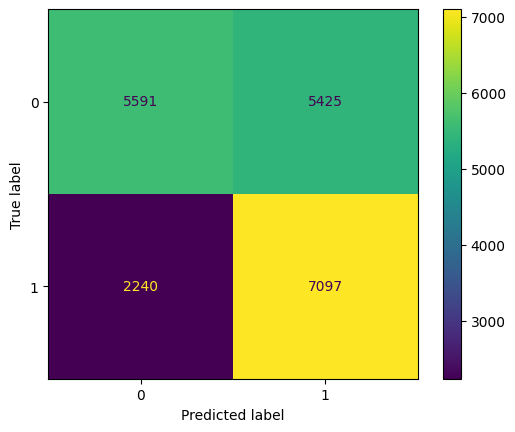

In [41]:
from xgboost import XGBClassifier

xgboost_pipeline = Pipeline(steps= [
    ('preprocessor',preprocessor),
    ('Model',XGBClassifier(n_estimators=200,
        learning_rate=0.2,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42))
])


xgboost_pipeline.fit(x_train, y_train)


xgboost_y_prob = xgboost_pipeline.predict_proba(x_test)[:, 1]

## FIXED THRESHOLD
THRESHOLD = 0.40

## Prediction    
xgboost_y_predict = (xgboost_y_prob >= THRESHOLD).astype(int)

## Evaluation 

print("\nDeployment Threshold:", THRESHOLD)
print("\nTest Accuracy:\n",accuracy_score(y_test,xgboost_y_predict))

print("\nReadmission Precision:\n",precision_score(y_test, xgboost_y_predict))

print("\nReadmission Recall:\n",recall_score(y_test, xgboost_y_predict))

print("\nReadmission F1:\n",f1_score(y_test, xgboost_y_predict))
    
print("\nROC-AUC:\n", roc_auc_score(y_test, xgboost_y_predict))

print("\nTEST CLASSIFICATION REPORT\n",classification_report(y_test, xgboost_y_predict))

cm = confusion_matrix(y_test, xgboost_y_predict)
print("\nCONFUSION MATRIX\n",cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()
plt.show()




## Model Comparison & Final Selection

Three models were evaluated for **Hospital readmission prediction** at a deployment threshold of **0.40**.

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---:|---:|---:|
| Test Accuracy | 58.45% | 61.03% | **62.34%** |
| Readmission Precision | 52.97% | 55.34% | **56.68%** |
| **Readmission Recall** | **84.01%** | 78.01% | 76.01% |
| **F1-score** | **64.98%** | 64.75% | 64.93% |
| ROC-AUC | 0.687 | **0.689** | 0.634 |
| False Negatives | **1,493** | 2,053 | 2,240 |

### Key Findings

- **Logistic Regression:** Highest **recall (84.01%)**, highest F1-score, and fewest false negatives. It identifies the most actual readmission cases.
- **Random Forest:** Highest **ROC-AUC (0.689)**, showing slightly stronger overall class discrimination.
- **XGBoost:** Highest **accuracy (62.34%)** and precision (56.68%), but lower recall and ROC-AUC.

### Final Model Selection

**Logistic Regression was selected as the primary readmission model** because the main objective is to identify patients at risk of readmission and minimize missed cases.

At the 0.40 threshold, it detects **84% of actual readmissions** and has only **1,493 false negatives**, compared with 2,053 for Random Forest and 2,240 for XGBoost.

> **Key takeaway:** For this healthcare use case, recall and minimizing false negatives are more important than accuracy alone. Therefore, Logistic Regression provides the most suitable operating point among the three models tested.

